# 05 – Monitoring Dashboard

Theo dõi hiệu năng mô hình theo thời gian thực:
1. Load prediction history
2. Rolling metrics (30-day / 90-day window)
3. Data drift detection (PSI – Population Stability Index)
4. Model drift alert
5. Dashboard tổng hợp

> **Run 04 trước.**

## 0 – Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config_loader import FEATURES_DIR, PROJECT_ROOT

PREDICTIONS_DIR = PROJECT_ROOT / 'data' / 'predictions'
MODELS_DIR      = PROJECT_ROOT / 'models'

# Tự động chọn prediction file đầu tiên tìm thấy
pred_files = sorted(PREDICTIONS_DIR.glob('predictions_*.parquet'))
if not pred_files:
    raise FileNotFoundError('[ERROR] Không tìm thấy file predictions_*.parquet – hãy run notebook 04 trước.')

PRED_FILE = pred_files[-1]   # file mới nhất
print(f'[INFO] Using: {PRED_FILE.name}')

[INFO] Using: predictions_xgboost.parquet


## 1 – Load Predictions

In [2]:
pred_df = pd.read_parquet(PRED_FILE)
pred_df.index = pd.to_datetime(pred_df.index)
pred_df.sort_index(inplace=True)

print(f'[INFO] Predictions: {pred_df.index.min().date()} → {pred_df.index.max().date()}')
print(f'[INFO] Shape       : {pred_df.shape}')
pred_df.head(5)

[INFO] Predictions: 2022-04-09 → 2023-10-04
[INFO] Shape       : (541, 5)


,actual,predicted,error,abs_error,pct_error
date,,,,,
2022-04-09,1941.6000,1943.3118,-1.7118,1.7118,0.0882
2022-04-10,1944.3000,1951.6030,-7.3030,7.3030,0.3756
2022-04-11,1972.1000,1962.3197,9.7803,9.7803,0.4959
2022-04-12,1981.0000,1978.8027,2.1973,2.1973,0.1109
2022-04-13,1970.9000,1968.4242,2.4758,2.4758,0.1256


## 2 – Rolling Metrics

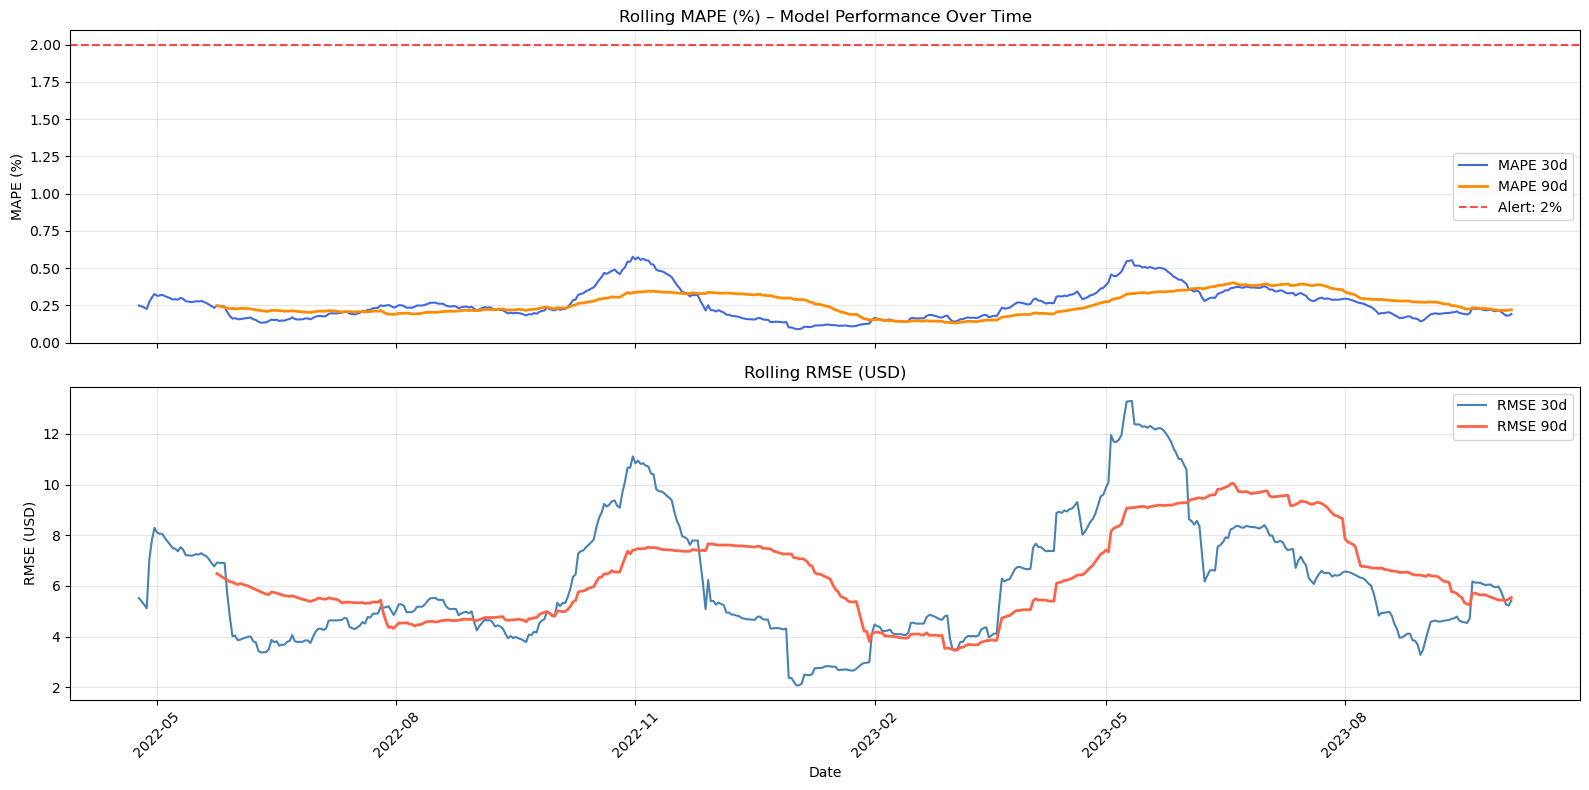

In [3]:
def rolling_mape(df, window):
    return (
        df['pct_error'].rolling(window, min_periods=window // 2).mean()
    )

def rolling_rmse(df, window):
    return (
        (df['error'] ** 2)
        .rolling(window, min_periods=window // 2)
        .mean()
        .apply(np.sqrt)
    )

W30  = 30
W90  = 90

pred_df['rolling_mape_30']  = rolling_mape(pred_df, W30)
pred_df['rolling_mape_90']  = rolling_mape(pred_df, W90)
pred_df['rolling_rmse_30']  = rolling_rmse(pred_df, W30)
pred_df['rolling_rmse_90']  = rolling_rmse(pred_df, W90)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax = axes[0]
ax.plot(pred_df.index, pred_df['rolling_mape_30'], label='MAPE 30d', color='royalblue', lw=1.5)
ax.plot(pred_df.index, pred_df['rolling_mape_90'], label='MAPE 90d', color='darkorange', lw=2)
ax.axhline(2, color='red', ls='--', alpha=0.7, label='Alert: 2%')
ax.set_title('Rolling MAPE (%) – Model Performance Over Time')
ax.set_ylabel('MAPE (%)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(pred_df.index, pred_df['rolling_rmse_30'], label='RMSE 30d', color='steelblue', lw=1.5)
ax.plot(pred_df.index, pred_df['rolling_rmse_90'], label='RMSE 90d', color='tomato', lw=2)
ax.set_title('Rolling RMSE (USD)')
ax.set_ylabel('RMSE (USD)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3 – Data Drift Detection (PSI)


[INFO] PSI Drift Report
  Actual prices : PSI = 7.9600  → 🚨 Major drift
  Predicted     : PSI = 8.2320  → 🚨 Major drift
  Residuals     : PSI = 0.4435  → 🚨 Major drift


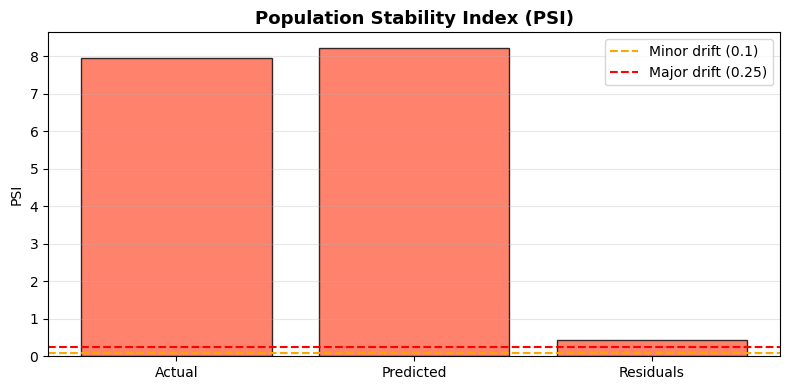

In [4]:
def psi(expected: np.ndarray, actual: np.ndarray, buckets: int = 10) -> float:
    """Population Stability Index.
    PSI < 0.1  → No drift
    PSI < 0.25 → Minor drift
    PSI >= 0.25 → Major drift
    """
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints[0]  -= 1e-6
    breakpoints[-1] += 1e-6

    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)

    exp_pct = np.where(exp_pct == 0, 1e-6, exp_pct)
    act_pct = np.where(act_pct == 0, 1e-6, act_pct)

    return np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))


# ── Chia 50% đầu (baseline) vs 50% sau (current) ──────────────────────────
mid    = len(pred_df) // 2
base   = pred_df.iloc[:mid]
curr   = pred_df.iloc[mid:]

psi_actual    = psi(base['actual'].values,    curr['actual'].values)
psi_predicted = psi(base['predicted'].values, curr['predicted'].values)
psi_error     = psi(base['error'].values,     curr['error'].values)

def psi_label(v):
    if v < 0.1:  return '✅ No drift'
    if v < 0.25: return '⚠️  Minor drift'
    return '🚨 Major drift'

print('\n[INFO] PSI Drift Report')
print(f'  Actual prices : PSI = {psi_actual:.4f}  → {psi_label(psi_actual)}')
print(f'  Predicted     : PSI = {psi_predicted:.4f}  → {psi_label(psi_predicted)}')
print(f'  Residuals     : PSI = {psi_error:.4f}  → {psi_label(psi_error)}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Actual', 'Predicted', 'Residuals']
values = [psi_actual, psi_predicted, psi_error]
colors = ['seagreen' if v < 0.1 else ('gold' if v < 0.25 else 'tomato') for v in values]
ax.bar(labels, values, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(0.1,  color='orange', ls='--', lw=1.5, label='Minor drift (0.1)')
ax.axhline(0.25, color='red',    ls='--', lw=1.5, label='Major drift (0.25)')
ax.set_title('Population Stability Index (PSI)', fontsize=13, fontweight='bold')
ax.set_ylabel('PSI')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4 – Model Drift Alert (CUSUM)

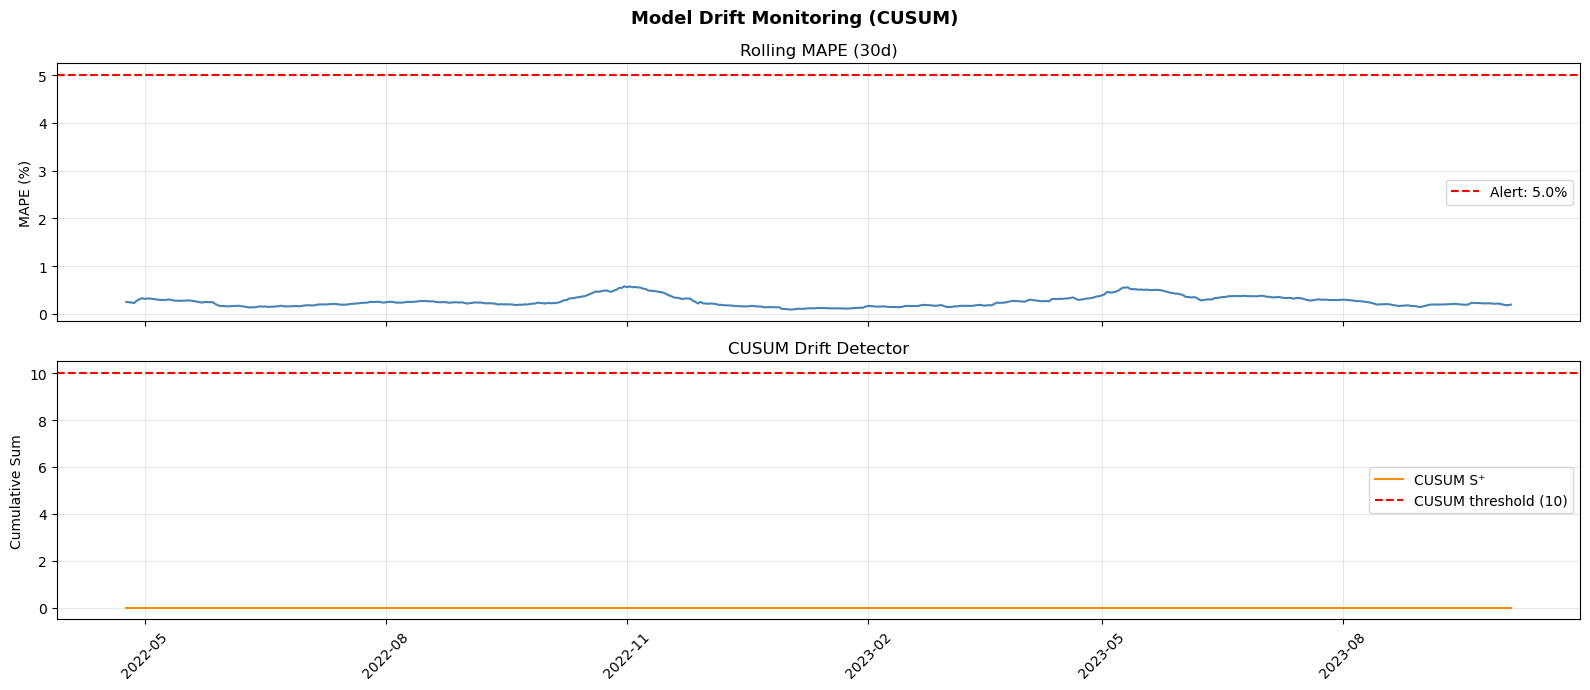

[INFO] CUSUM alerts detected: 0 days
[OK]   No persistent drift detected.


In [5]:
# CUSUM trên MAPE 30-day rolling – phát hiện degradation liên tục
ALERT_THRESHOLD = 5.0    # MAPE 5% là mức cảnh báo
CUSUM_K         = 0.5    # slack

mape_series = pred_df['rolling_mape_30'].dropna()
mu0 = mape_series.iloc[:90].mean()    # baseline từ 90 ngày đầu

S_hi = np.zeros(len(mape_series))
for i in range(1, len(mape_series)):
    S_hi[i] = max(0, S_hi[i-1] + mape_series.iloc[i] - mu0 - CUSUM_K)

cusum_df = pd.DataFrame({
    'MAPE_30d' : mape_series.values,
    'CUSUM'    : S_hi,
}, index=mape_series.index)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(cusum_df.index, cusum_df['MAPE_30d'], color='steelblue', lw=1.5)
axes[0].axhline(ALERT_THRESHOLD, color='red', ls='--', label=f'Alert: {ALERT_THRESHOLD}%')
axes[0].set_title('Rolling MAPE (30d)')
axes[0].set_ylabel('MAPE (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(cusum_df.index, cusum_df['CUSUM'], color='darkorange', lw=1.5, label='CUSUM S⁺')
axes[1].axhline(10, color='red', ls='--', label='CUSUM threshold (10)')
alert_idx = cusum_df.index[cusum_df['CUSUM'] > 10]
if len(alert_idx):
    axes[1].scatter(alert_idx, cusum_df.loc[alert_idx, 'CUSUM'], color='red', s=20, zorder=5, label='Drift alert')
axes[1].set_title('CUSUM Drift Detector')
axes[1].set_ylabel('Cumulative Sum')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.suptitle('Model Drift Monitoring (CUSUM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

n_alerts = (cusum_df['CUSUM'] > 10).sum()
print(f'[INFO] CUSUM alerts detected: {n_alerts} days')
if n_alerts > 0:
    print(f'[WARN] Model degradation detected – consider retraining!')
else:
    print(f'[OK]   No persistent drift detected.')

## 5 – Dashboard Tổng Hợp

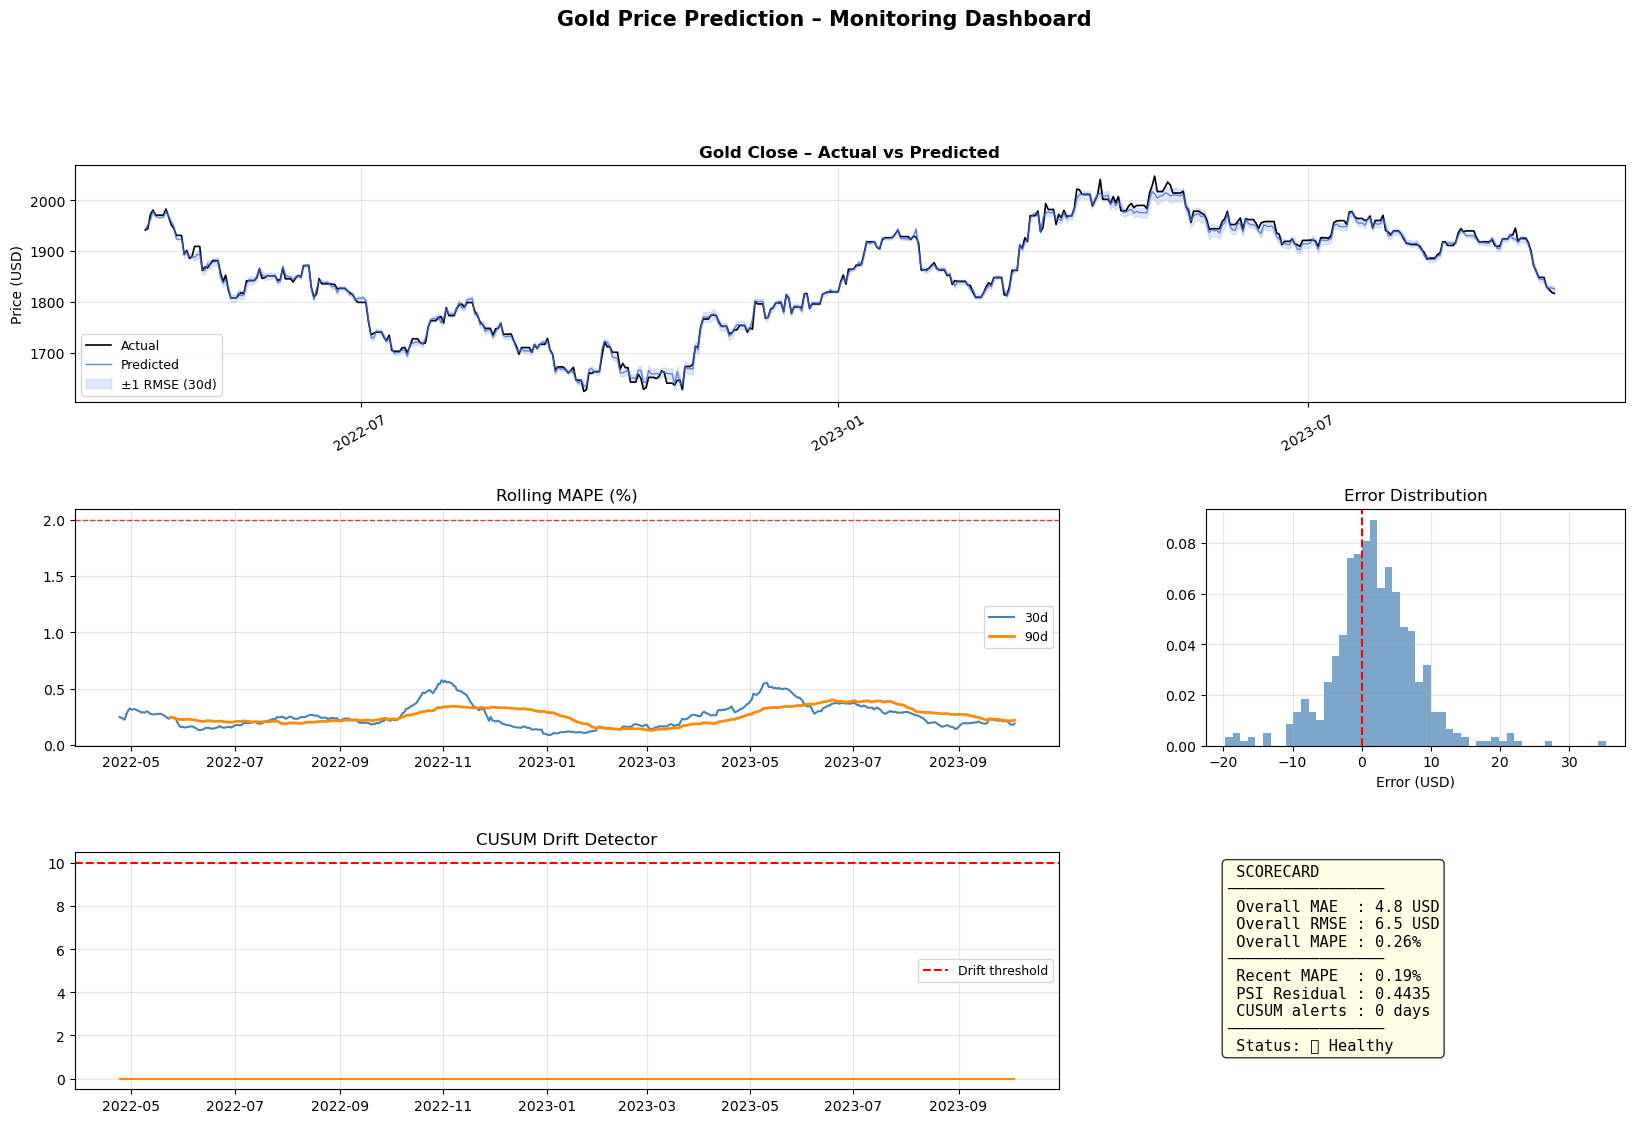

[OK] Dashboard saved → P:\study_again\gold_time_prediction\data\predictions\monitoring_dashboard.png


In [6]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Actual vs Predicted (tất cả) ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(pred_df.index, pred_df['actual'],    label='Actual',    color='black', lw=1.2)
ax1.plot(pred_df.index, pred_df['predicted'], label='Predicted', color='royalblue', alpha=0.8, lw=1)
ax1.fill_between(
    pred_df.index,
    pred_df['predicted'] - pred_df['rolling_rmse_30'].fillna(0),
    pred_df['predicted'] + pred_df['rolling_rmse_30'].fillna(0),
    alpha=0.15, color='royalblue', label='±1 RMSE (30d)'
)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
ax1.set_title('Gold Close – Actual vs Predicted', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── Panel 2: Rolling MAPE ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0:2])
ax2.plot(pred_df.index, pred_df['rolling_mape_30'], label='30d', color='steelblue', lw=1.5)
ax2.plot(pred_df.index, pred_df['rolling_mape_90'], label='90d', color='darkorange', lw=2)
ax2.axhline(2, color='red', ls='--', lw=1, alpha=0.8)
ax2.set_title('Rolling MAPE (%)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ── Panel 3: Error Distribution ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.hist(pred_df['error'], bins=50, color='steelblue', alpha=0.7, density=True)
ax3.axvline(0, color='red', lw=1.5, ls='--')
ax3.set_title('Error Distribution')
ax3.set_xlabel('Error (USD)')
ax3.grid(alpha=0.3)

# ── Panel 4: CUSUM ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0:2])
ax4.plot(cusum_df.index, cusum_df['CUSUM'], color='darkorange', lw=1.5)
ax4.axhline(10, color='red', ls='--', lw=1.5, label='Drift threshold')
ax4.set_title('CUSUM Drift Detector')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# ── Panel 5: KPI Scorecard ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
overall_mae  = pred_df['abs_error'].mean()
overall_mape = pred_df['pct_error'].mean()
overall_rmse = np.sqrt((pred_df['error'] ** 2).mean())
recent_mape  = pred_df['rolling_mape_30'].iloc[-1]
kpi_text = (
    f" SCORECARD\n"
    f"─────────────────\n"
    f" Overall MAE  : {overall_mae:.1f} USD\n"
    f" Overall RMSE : {overall_rmse:.1f} USD\n"
    f" Overall MAPE : {overall_mape:.2f}%\n"
    f"─────────────────\n"
    f" Recent MAPE  : {recent_mape:.2f}%\n"
    f" PSI Residual : {psi_error:.4f}\n"
    f" CUSUM alerts : {n_alerts} days\n"
    f"─────────────────\n"
    f" Status: {'🚨 Retrain' if n_alerts > 30 else '✅ Healthy'}"
)
ax5.text(0.05, 0.95, kpi_text, transform=ax5.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Gold Price Prediction – Monitoring Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(PREDICTIONS_DIR / 'monitoring_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[OK] Dashboard saved → {PREDICTIONS_DIR / "monitoring_dashboard.png"}')

## 6 – Tóm Tắt & Khuyến Nghị

In [7]:
print('=' * 55)
print(' GOLD PRICE PREDICTION – MONITORING SUMMARY')
print('=' * 55)
print(f' Model file   : {PRED_FILE.name}')
print(f' Test period  : {pred_df.index.min().date()} → {pred_df.index.max().date()}')
print(f' Test rows    : {len(pred_df)}')
print(f'')
print(f' Overall MAE  : {overall_mae:.2f} USD')
print(f' Overall RMSE : {overall_rmse:.2f} USD')
print(f' Overall MAPE : {overall_mape:.2f}%')
print(f'')
print(f' PSI (residuals) : {psi_error:.4f}  → {psi_label(psi_error)}')
print(f' CUSUM alerts    : {n_alerts} days')
print(f'')
if n_alerts > 30:
    print(' [WARN] Model drift detected – khuyến nghị retrain!')
else:
    print(' [OK]   Model ổn định, không cần retrain ngay.')
print('=' * 55)

 GOLD PRICE PREDICTION – MONITORING SUMMARY
 Model file   : predictions_xgboost.parquet
 Test period  : 2022-04-09 → 2023-10-04
 Test rows    : 541

 Overall MAE  : 4.77 USD
 Overall RMSE : 6.53 USD
 Overall MAPE : 0.26%

 PSI (residuals) : 0.4435  → 🚨 Major drift
 CUSUM alerts    : 0 days

 [OK]   Model ổn định, không cần retrain ngay.
